# Flow Matching & Rectified Flow Notebook (Konvertiert aus Alex_DDPM)
Dieses Notebook implementiert ein generatives Modell basierend auf Flow Matching (FM) und Rectified Flow (RF) unter Verwendung einer U-Net Architektur. Es nutzt dieselben Input-Daten und Pfade wie das vorherige DDPM-Notebook, um einen direkten Vergleich zu ermöglichen.

Zelle 2: Code – Imports, Google Drive & Konfiguration

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. AUTOMATIC ENVIRONMENT SWITCH
# ==========================================
try:
    import google.colab
    IS_COLAB = True
    print("[INFO] 🌎 Running on GOOGLE COLAB. Activating Cloud Paths.")
except ImportError:
    IS_COLAB = False
    print("[INFO] 💻 Running LOCALLY on ZBook. Activating Local Paths.")

# ==========================================
# 2. DYNAMIC PATH CONFIGURATION
# ==========================================
if IS_COLAB:
    print("[INFO] Verbinde mit Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = "/content/drive/MyDrive/Alex_RM"
    DRIVE_TRAIN_DATA = "/content/drive/MyDrive/celeb064"
else:
    DRIVE_BASE = "./Alex_RM"
    DRIVE_TRAIN_DATA = "C:/Data/celeb064"

DRIVE_CHECKPOINTS = DRIVE_BASE + "/Checkpoints_FM"
DRIVE_CHECKPOINTS_RF = DRIVE_BASE + "/Checkpoints_RF"
DRIVE_OUTPUT_IMAGES = DRIVE_BASE + "/Output_Images_FM"
os.makedirs(DRIVE_CHECKPOINTS, exist_ok=True)
os.makedirs(DRIVE_CHECKPOINTS_RF, exist_ok=True)
os.makedirs(DRIVE_OUTPUT_IMAGES, exist_ok=True)

# ==========================================
# 3. RUN CONTROL (CENTRAL CONFIGURATION)
# ==========================================
TEST_MODE = True           # True = quick 2-min pipeline test, False = full 24h training
FORCE_CPU = False          # False = use GPU (CUDA) if available, True = force CPU fallback
AUTO_RESUME = True         # True = auto-detect and resume from latest checkpoint, False = start fresh

# Hardware Setup
if FORCE_CPU:
    Device = torch.device("cpu")
else:
    Device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 2e-4
IMAGE_SIZE = 64
EPOCHS = 5 if TEST_MODE else 200  # Will be adjusted dynamically if resuming

# Test Mode limits
TEST_IMAGE_LIMIT = 160     # Anzahl der Bilder fuer den Schnelltest (z. B. 10 Batches von Gr. 16)


[INFO] 💻 Running LOCALLY on ZBook. Activating Local Paths.


Zelle 3: Code – Dataset & DataLoader

In [2]:
class BildDatensatz(Dataset):
    def __init__(self, ordner_pfad, bild_groesse=64, test_mode=False, test_limit=160):
        self.ordner_pfad = ordner_pfad

        # Durchsucht den Ordner nach Bildern. Falls Unterordner existieren,
        # werden diese ebenfalls berücksichtigt (wichtig für Datensätze wie CelebA)
        self.dateien = []
        for root, dirs, files in os.walk(ordner_pfad):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.dateien.append(os.path.join(root, file))
        
        # Limit dataset size to test_limit if in test mode
        if test_mode:
            self.dateien = self.dateien[:test_limit]
            print(f"[INFO] TEST_MODE aktiv: Datensatz auf {len(self.dateien)} Bilder limitiert.")

        self.transform = transforms.Compose([
            transforms.Resize((bild_groesse, bild_groesse)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Bereich [-1, 1]
        ])

    def __len__(self):
        return len(self.dateien)

    def __getitem__(self, index):
        bild_pfad = self.dateien[index]
        bild = Image.open(bild_pfad).convert("RGB")
        return self.transform(bild)

# Initialisiere Daten-Pipeline
print(f"[INFO] Suche nach Bildern unter: {DRIVE_TRAIN_DATA}")

if os.path.exists(DRIVE_TRAIN_DATA):
    Mein_Datensatz = BildDatensatz(DRIVE_TRAIN_DATA, bild_groesse=IMAGE_SIZE, test_mode=TEST_MODE, test_limit=TEST_IMAGE_LIMIT)
    if len(Mein_Datensatz) > 0:
        Mein_DataLoader = DataLoader(Mein_Datensatz, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        print(f"[ERFOLG] Datensatz gefunden! Echte Bilder erfolgreich geladen: {len(Mein_Datensatz)}")
    else:
        print("[FEHLER] Der Ordner existiert, enthält aber keine gültigen Bilddateien (.png, .jpg)!")
else:
    print(f"[HINWEIS] Pfad {DRIVE_TRAIN_DATA} nicht gefunden.")
    print("-> Nutze Dummy-Fallback (Zufallsrauschen) für den Pipeline-Test...")
    dummy_bilder = torch.randn(32, 3, IMAGE_SIZE, IMAGE_SIZE)
    dummy_bilder = torch.clamp(dummy_bilder, -1.0, 1.0)
    Mein_DataLoader = DataLoader(dummy_bilder, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


[INFO] Suche nach Bildern unter: C:/Data/celeb064
[INFO] TEST_MODE aktiv: Datensatz auf 160 Bilder limitiert.
[ERFOLG] Datensatz gefunden! Echte Bilder erfolgreich geladen: 160


Zelle 4: Code – Die U-Net Architektur (SimpleUNet)

In [3]:
import torch
import torch.nn as nn
import numpy as np

# 1. ZEIT-EMBEDDINGS (Unchanged)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, : ]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 2. DER KORRIGIERTE BAUSTEIN-BLOCK
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.up = up
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            # The up-block receives concatenated channels (2 * in_ch)
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.downsample = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # standard convolutions and time embedding addition
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))

        # Downsample AFTER the block processing if we are in the down-path
        if not self.up:
            return h, self.downsample(h) # Return both the pre-downsample feature (for skip connection) and downsampled feature
        return h

# 3. DAS KORRIGIERTE U-NET
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels = (512, 256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Down-Blöcke
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels)-1)
        ])

        # Up-Sampling Transpose Convolutions placed in the UNet loop
        self.upsamples = nn.ModuleList([
            nn.ConvTranspose2d(up_channels[i], up_channels[i], 4, 2, 1)
            for i in range(len(up_channels)-1)
        ])

        # Up-Blöcke
        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels)-1)
        ])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.conv0(x)
        residual_inputs = []

        # Down-Pfad
        for down in self.downs:
            # Keep the features before downsampling to pass as a skip connection
            skip_connection, x = down(x, t)
            residual_inputs.append(skip_connection)

        # Up-Pfad
        for i, up in enumerate(self.ups):
            # 1. Upsample current features first
            x = self.upsamples[i](x)

            # 2. Pop the corresponding skip connection
            residual_x = residual_inputs.pop()

            # 3. Concatenate (Both are now perfectly aligned in spatial size)
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)

# 4. INITIALISIERUNG
Modell = SimpleUNet().to(Device)
Optimizer = optim.Adam(Modell.parameters(), lr=LEARNING_RATE)
Criterion = nn.MSELoss()
print("[INFO] Das U-Net wurde architektonisch korrigiert und für FM_RM neu initialisiert!")

[INFO] Das U-Net wurde architektonisch korrigiert und für FM_RM neu initialisiert!


Zelle 5: Markdown

## Flow Matching & Rectified Flow mathematischer Hintergrund
Im Gegensatz zu DDPM (das auf diskreten Zeitschritten von z. B. 1000 herunterzählt und Rauschen vorhersagt) lernt **Flow Matching** ein Vektorfeld $v_t(x)$, das Datenpunkte geradlinig von reinem Rauschen ($x_0$) zu echten Bildern ($x_1$) transformiert.
Die Interpolation lautet:
$$x_t = x_0 + t \cdot (x_1 - x_0)$$
Das Ziel (Target) für das Netzwerk ist die konstante Richtung:
$$v_{target} = x_1 - x_0$$

Zelle 6: Code – Die Trainings-Schleife (Phase 1: Flow Matching)

In [4]:
import os
import re
import sys
import torch

# 1. SCAN DIRECTORIES FOR CHECKPOINTS
p1_checkpoint = None
p1_final = os.path.exists(os.path.join(DRIVE_CHECKPOINTS, "flow_matching_final_checkpoint.pth"))
p2_checkpoint = None
p2_final = os.path.exists(os.path.join(DRIVE_CHECKPOINTS_RF, "rectified_flow_final.pth"))

if os.path.exists(DRIVE_CHECKPOINTS):
    files = os.listdir(DRIVE_CHECKPOINTS)
    epochs = []
    for f in files:
        m = re.match(r"flow_matching_checkpoint_epoch_(\d+)\.pth", f)
        if m:
            epochs.append(int(m.group(1)))
    if epochs:
        p1_checkpoint = max(epochs)

if os.path.exists(DRIVE_CHECKPOINTS_RF):
    files = os.listdir(DRIVE_CHECKPOINTS_RF)
    epochs = []
    for f in files:
        m = re.match(r"rectified_flow_checkpoint_epoch_(\d+)\.pth", f)
        if m:
            epochs.append(int(m.group(1)))
    if epochs:
        p2_checkpoint = max(epochs)

# HIER DIE EPOCHE ANGEBEN, VON DER AUS DU FORTSETZEN MÖCHTEST
RESUME_FROM_EPOCH = 0 # Set to 0 to start fresh from epoch 1, or change to checkpoint epoch to resume
checkpoint_load_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{RESUME_FROM_EPOCH}.pth"

if os.path.exists(checkpoint_load_path):
    print(f"[INFO] Lade Checkpoint von Drive: {checkpoint_load_path}")

    # Checkpoint-Datei einlesen
    checkpoint = torch.load(checkpoint_load_path, map_location=Device)

    # 1. Modellgewichte wiederherstellen
    Modell.load_state_dict(checkpoint['model_state_dict'])

    # 2. Optimierer-Zustand wiederherstellen
    Optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # 3. Start-Epoche für die Trainingsschleife anpassen (Nächste Epoche)
    START_EPOCH = checkpoint['epoch'] + 1
    
    # Dynamisch die Gesamtanzahl der Epochen (EPOCHS) anpassen:
    if TEST_MODE:
        EPOCHS = START_EPOCH + 4  # In TEST_MODE wollen wir genau 5 Epochen ab START_EPOCH trainieren
    else:
        if EPOCHS < START_EPOCH:
            EPOCHS = START_EPOCH + (200 - checkpoint['epoch']) # Stellt sicher, dass das vollständige Resttraining stattfindet

    print(f"[ERFOLG] Daten geladen. Training wird ab Epoche {START_EPOCH} fortgesetzt!")
else:
    print(f"[WARNUNG] Kein Checkpoint für Epoche {RESUME_FROM_EPOCH} gefunden. Starte komplett neu ab Epoche 1.")
    START_EPOCH = 1

# 2. DETERMINE TRAINING STATES AND RESUME FLAGS
START_EPOCH_RF = 1
SKIP_PHASE_1 = False
SKIP_PHASE_2 = False
state_description = "Starte komplett neu ab Epoche 1."

if AUTO_RESUME:
    if p2_final:
        SKIP_PHASE_1 = True
        SKIP_PHASE_2 = True
        state_description = "Training vollstaendig abgeschlossen (Phase 2 beendet)."
    elif p2_checkpoint is not None:
        SKIP_PHASE_1 = True
        START_EPOCH_RF = p2_checkpoint + 1
        state_description = f"Unterbrochen in Phase 2 (Rectified Flow). Setze ab Epoche {START_EPOCH_RF} fort."
    elif p1_final:
        SKIP_PHASE_1 = True
        START_EPOCH_RF = 1
        state_description = "Phase 1 abgeschlossen. Setze fort mit Phase 2 ab Epoche 1."
    elif p1_checkpoint is not None:
        START_EPOCH = p1_checkpoint + 1
        state_description = f"Unterbrochen in Phase 1 (Flow Matching). Setze ab Epoche {START_EPOCH} fort."
else:
    state_description = "AUTO_RESUME deaktiviert. Starte komplett neu ab Epoche 1."

# Dynamically correct EPOCHS based on START_EPOCH
if TEST_MODE:
    if not SKIP_PHASE_1:
        EPOCHS = START_EPOCH + 4
    else:
        EPOCHS = START_EPOCH_RF + 4
else:
    if not SKIP_PHASE_1:
        if EPOCHS < START_EPOCH:
            EPOCHS = START_EPOCH + (200 - p1_checkpoint if p1_checkpoint else 200)
    else:
        if EPOCHS < START_EPOCH_RF:
            EPOCHS = START_EPOCH_RF + (200 - p2_checkpoint if p2_checkpoint else 200)

# 3. PRINT CONFIGURATION PREVIEW
print("=" * 60)
print("              RUN CONFIGURATION PREVIEW")
print("=" * 60)
print(f"* Training-Modus:   {'TEST_MODE (Schnelltest)' if TEST_MODE else 'PRODUCTION (Vollstaendiges Training)'}")
print(f"* Hardware Geraet:  {str(Device).upper()}")
print(f"* Batch-Groesse:      {BATCH_SIZE} | Bild-Groesse: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"* Lernrate:         {LEARNING_RATE}")
print(f"* Ziel-Epochen:     {EPOCHS}")
print(f"* Erkannter Status: {state_description}")
print("=" * 60)

# 4. INTERACTIVE CONTINUATION PROMPT
user_input = "y"
if not (SKIP_PHASE_1 and SKIP_PHASE_2):
    try:
        try:
            from ipykernel.kernelbase import StdinNotImplementedError
        except ImportError:
            class StdinNotImplementedError(Exception): pass
            
        user_input = input("Moechten Sie das Training fortsetzen/starten? (y/n): ").strip().lower()
    except (EOFError, IOError, StdinNotImplementedError):
        print("[INFO] Headless/Non-interaktiv Modus erkannt. Training startet automatisch.")
        user_input = "y"
        
    if user_input != 'y':
        raise KeyboardInterrupt("Training abgebrochen durch Benutzer.")
    else:
        print("[INFO] Starten...")
else:
    print("[INFO] Keine weiteren Trainingsschritte erforderlich.")


[WARNUNG] Kein Checkpoint für Epoche 0 gefunden. Starte komplett neu ab Epoche 1.
              RUN CONFIGURATION PREVIEW
* Training-Modus:   TEST_MODE (Schnelltest)
* Hardware Geraet:  CUDA
* Batch-Groesse:      16 | Bild-Groesse: 64x64
* Lernrate:         0.0002
* Ziel-Epochen:     5
* Erkannter Status: Starte komplett neu ab Epoche 1.
[INFO] Headless/Non-interaktiv Modus erkannt. Training startet automatisch.
[INFO] Starten...


In [5]:
print("[INFO] Starte Training Phase 1: Flow Matching...")

if not SKIP_PHASE_1:
    Modell.train()
    for Epoche in range(START_EPOCH, EPOCHS + 1):
        Gesamt_Loss = 0.0
        for Bildelemente in Mein_DataLoader:
            Optimizer.zero_grad()

            x1 = Bildelemente.to(Device)
            x0 = torch.randn_like(x1).to(Device)

            t = torch.rand((x1.shape[0],), device=Device)
            t_expand = t[:, None, None, None]
            xt = x0 + t_expand * (x1 - x0)

            v_target = x1 - x0
            v_pred = Modell(xt, t)

            Loss = Criterion(v_pred, v_target)
            Loss.backward()
            Optimizer.step()

            Gesamt_Loss += Loss.item()

        Durchschnitts_Loss = Gesamt_Loss / len(Mein_DataLoader)

        if Epoche % 10 == 0 or Epoche == 1 or Epoche == EPOCHS:
            print(f"Epoche [{Epoche}/{EPOCHS}] -> Durchschnittlicher Loss: {Durchschnitts_Loss:.6f}")

        # Sichern von Zwischen-Checkpoints
        if Epoche % 25 == 0 or (TEST_MODE and Epoche % 1 == 0):
            checkpoint_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{Epoche}.pth"
            torch.save({
                'epoch': Epoche,
                'model_state_dict': Modell.state_dict(),
                'optimizer_state_dict': Optimizer.state_dict(),
                'loss': Durchschnitts_Loss,
            }, checkpoint_path)
            print(f"[INFO] Checkpoint gesichert: {checkpoint_path}")

    # Finale Gewichte sichern
    torch.save({
        'epoch': EPOCHS,
        'model_state_dict': Modell.state_dict(),
        'optimizer_state_dict': Optimizer.state_dict(),
        'loss': Durchschnitts_Loss,
    }, DRIVE_CHECKPOINTS + "/flow_matching_final_checkpoint.pth")
    print("[INFO] Training Phase 1 abgeschlossen und alle finalen Daten gesichert.")
else:
    print("[INFO] Phase 1 (Flow Matching) wird uebersprungen. Lade finalen Checkpoint...")
    checkpoint_path = DRIVE_CHECKPOINTS + "/flow_matching_final_checkpoint.pth"
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=Device)
        Modell.load_state_dict(checkpoint['model_state_dict'])
        print("[ERFOLG] Finaler Phase 1 Checkpoint erfolgreich geladen.")
    else:
        latest_checkpoint_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{p1_checkpoint}.pth"
        if os.path.exists(latest_checkpoint_path):
            checkpoint = torch.load(latest_checkpoint_path, map_location=Device)
            Modell.load_state_dict(checkpoint['model_state_dict'])
            print(f"[ERFOLG] Zwischen-Checkpoint fuer Epoche {p1_checkpoint} geladen.")
        else:
            raise FileNotFoundError("Konnte keinen Phase 1 Checkpoint zum Laden finden!")


[INFO] Starte Training Phase 1: Flow Matching...


Epoche [1/5] -> Durchschnittlicher Loss: 0.942796


[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_1.pth


[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_2.pth


[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_3.pth


[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_4.pth


Epoche [5/5] -> Durchschnittlicher Loss: 0.369537
[INFO] Checkpoint gesichert: ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_5.pth


[INFO] Training Phase 1 abgeschlossen und alle finalen Daten gesichert.


Zelle 7: Code – Bildgenerierung über ODE-Solver (Inferenz / Sampling)

In [6]:
# 1. Define the path to the specific checkpoint you want to test
EVAL_EPOCH = 100
checkpoint_eval_path = DRIVE_CHECKPOINTS + f"/flow_matching_checkpoint_epoch_{EVAL_EPOCH}.pth"

if os.path.exists(checkpoint_eval_path):
    print(f"[INFO] Loading specific checkpoint for image generation: {checkpoint_eval_path}")

    # Load the checkpoint file
    checkpoint = torch.load(checkpoint_eval_path, map_location=Device)

    # Apply the saved weights to your model
    Modell.load_state_dict(checkpoint['model_state_dict'])
    print(f"[SUCCESS] Model is now set to Epoch {EVAL_EPOCH} weights!")
else:
    print(f"[ERROR] Could not find a checkpoint for epoch {EVAL_EPOCH} at {checkpoint_eval_path}")
    print("Please check your Google Drive folder structure.")

[ERROR] Could not find a checkpoint for epoch 100 at ./Alex_RM/Checkpoints_FM/flow_matching_checkpoint_epoch_100.pth
Please check your Google Drive folder structure.


[INFO] Generiere Testbilder aus dem trainierten Flow-Feld...


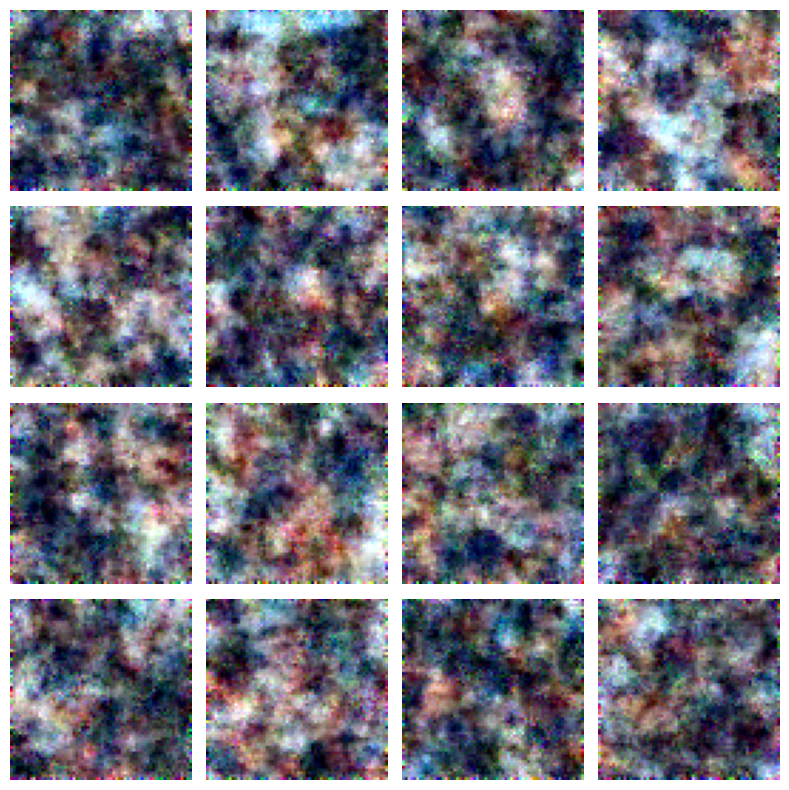

In [7]:
def Entferne_Normierung(img_tensor):
    """ Skaliert das Bild zurück von [-1, 1] auf [0, 1] für Matplotlib """
    img_tensor = (img_tensor + 1.0) / 2.0
    return torch.clamp(img_tensor, 0.0, 1.0)

@torch.no_grad()
def Generiere_Bilder_Flow_Matching(modell, anzahl_bilder=16, steps=50):
    modell.eval()
    dt = 1.0 / steps

    # Starte mit purem Gauß-Rauschen am Zeitschritt t = 0
    xt = torch.randn((anzahl_bilder, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)

    # Integriere das Vektorfeld vorwärts von t = 0 bis t = 1 (Euler-Verfahren)
    for step in range(steps):
        t_val = step * dt
        t_tensor = torch.full((anzahl_bilder,), t_val, device=Device)

        # Schätze die Richtung/Geschwindigkeit v
        v = modell(xt, t_tensor)

        # Euler Schritt: Gehe ein Stück in Richtung des echten Bildes
        xt = xt + v * dt

    return Entferne_Normierung(xt)

# Teste die Bildgenerierung
print("[INFO] Generiere Testbilder aus dem trainierten Flow-Feld...")
Generierte_Bilder = Generiere_Bilder_Flow_Matching(Modell, anzahl_bilder=16, steps=50)

# Plotten und Speichern des Outputs (Exakt gleiches Format wie bei DDPM)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
Generierte_Bilder = Generierte_Bilder.cpu().permute(0, 2, 3, 1).numpy()

for i, ax in enumerate(axes.flat):
    ax.imshow(Generierte_Bilder[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_IMAGES + "/flow_matching_output_grid.png")
plt.show()

Zelle 8: Markdown

## Optionaler Schritt: Reflow (2-RF) für perfekt begradigte Pfade
Wenn du wie im bereitgestellten `FMvsRM` Notebook die Trajektorien weiter begradigen möchtest (um z. B. Bilder in nur einem einzigen Schritt generieren zu können), führen wir nun den **Reflow-Schritt** durch. Hierzu erzeugen wir synthetisch begradigte Paare $(x_0, x_{1, rectified})$ mithilfe des soeben trainierten Modells.

Zelle 9: Code – Durchführung des Reflow-Trainings (Phase 2)

In [8]:
# Speicherpfad fuer Phase 2 erstellen
DRIVE_CHECKPOINTS_RF = DRIVE_BASE + "/Checkpoints_RF"
os.makedirs(DRIVE_CHECKPOINTS_RF, exist_ok=True)

if not SKIP_PHASE_2:
    print("[INFO] Generiere begradigte Datenpunkte (Reflow) ...")
    Begradigter_Datensatz = []
    Modell.eval()
    with torch.no_grad():
        for Bildelemente in Mein_DataLoader:
            x1_real = Bildelemente.to(Device)
            x0_noise = torch.randn_like(x1_real).to(Device)

            # Loese die ODE bis t=1 um die rektifizierten Endpunkte zu finden
            xt = x0_noise.clone()
            steps = 10 if TEST_MODE else 50
            dt = 1.0 / steps
            for step in range(steps):
                t_tensor = torch.full((x1_real.shape[0],), step * dt, device=Device)
                v = Modell(xt, t_tensor)
                xt = xt + v * dt

            # Speichere die Paare (Rauschen, generiertes Bild) ab
            Begradigter_Datensatz.append((x0_noise.cpu(), xt.cpu()))

    print("[INFO] Starte Phase 2: Training des Rectified Flow Modells...")
    Modell_RF = SimpleUNet().to(Device)
    Optimizer_RF = optim.Adam(Modell_RF.parameters(), lr=LEARNING_RATE)

    # Falls wir fortsetzen, lade den letzten Zwischenstand
    if START_EPOCH_RF > 1:
        checkpoint_rf_path = DRIVE_CHECKPOINTS_RF + f"/rectified_flow_checkpoint_epoch_{START_EPOCH_RF - 1}.pth"
        if os.path.exists(checkpoint_rf_path):
            print(f"[INFO] Lade Phase 2 Checkpoint: {checkpoint_rf_path}")
            checkpoint_rf = torch.load(checkpoint_rf_path, map_location=Device)
            Modell_RF.load_state_dict(checkpoint_rf['model_state_dict'])
            Optimizer_RF.load_state_dict(checkpoint_rf['optimizer_state_dict'])
            print(f"[ERFOLG] Phase 2 Training wird ab Epoche {START_EPOCH_RF} fortgesetzt!")
        else:
            print(f"[WARNUNG] Checkpoint {checkpoint_rf_path} nicht gefunden. Starte Phase 2 neu ab Epoche 1.")
            START_EPOCH_RF = 1

    Modell_RF.train()
    # Bestimme die Ziel-Epoche fuer Phase 2
    target_rf_epochs = START_EPOCH_RF + 4 if TEST_MODE else 200
    
    for Epoche in range(START_EPOCH_RF, target_rf_epochs + 1):
        Gesamt_Loss_RF = 0.0
        for x0, x1_rectified in Begradigter_Datensatz:
            Optimizer_RF.zero_grad()

            x0 = x0.to(Device)
            x1_rect = x1_rectified.to(Device)

            t = torch.rand((x0.shape[0],), device=Device)
            t_expand = t[:, None, None, None]

            # Linearer Pfad auf den begradigten Datenpaaren
            xt = x0 + t_expand * (x1_rect - x0)
            v_target = x1_rect - x0

            v_pred = Modell_RF(xt, t)
            Loss = Criterion(v_pred, v_target)
            Loss.backward()
            Optimizer_RF.step()

            Gesamt_Loss_RF += Loss.item()

        if Epoche % 10 == 0 or Epoche == 1 or Epoche == target_rf_epochs:
            print(f"RF-Epoche [{Epoche}/{target_rf_epochs}] -> Loss: {Gesamt_Loss_RF / len(Begradigter_Datensatz):.6f}")

        # Speichern von Zwischen-Checkpoints in Phase 2
        if Epoche % 25 == 0 or (TEST_MODE and Epoche % 1 == 0):
            checkpoint_path_rf = DRIVE_CHECKPOINTS_RF + f"/rectified_flow_checkpoint_epoch_{Epoche}.pth"
            torch.save({
                'epoch': Epoche,
                'model_state_dict': Modell_RF.state_dict(),
                'optimizer_state_dict': Optimizer_RF.state_dict(),
                'loss': Gesamt_Loss_RF / len(Begradigter_Datensatz),
            }, checkpoint_path_rf)
            print(f"[INFO] Phase 2 Checkpoint gesichert: {checkpoint_path_rf}")

    # Sichern am Ende
    torch.save(Modell_RF.state_dict(), DRIVE_CHECKPOINTS_RF + "/rectified_flow_final.pth")
    print("[ERFOLG] Rectified Flow Modell (2-RF) trainiert und final gespeichert.")
else:
    print("[INFO] Phase 2 (Rectified Flow) wird uebersprungen. Lade finalen Checkpoint...")
    Modell_RF = SimpleUNet().to(Device)
    final_path_rf = DRIVE_CHECKPOINTS_RF + "/rectified_flow_final.pth"
    if os.path.exists(final_path_rf):
        Modell_RF.load_state_dict(torch.load(final_path_rf, map_location=Device))
        print("[ERFOLG] Finales Phase 2 Modell erfolgreich geladen.")
    else:
        raise FileNotFoundError("Konnte kein finalisiertes Phase 2 Modell zum Laden finden!")


[INFO] Generiere begradigte Datenpunkte (Reflow) ...


[INFO] Starte Phase 2: Training des Rectified Flow Modells...


RF-Epoche [1/5] -> Loss: 0.496829


[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_1.pth


[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_2.pth


[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_3.pth


[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_4.pth


RF-Epoche [5/5] -> Loss: 0.112471
[INFO] Phase 2 Checkpoint gesichert: ./Alex_RM/Checkpoints_RF/rectified_flow_checkpoint_epoch_5.pth


[ERFOLG] Rectified Flow Modell (2-RF) trainiert und final gespeichert.


Zelle 10: Code – Inferenz-Vergleich (1-Step vs. Multi-Step)

[INFO] Generiere Bilder mit dem Rectified Flow (RF) Modell...


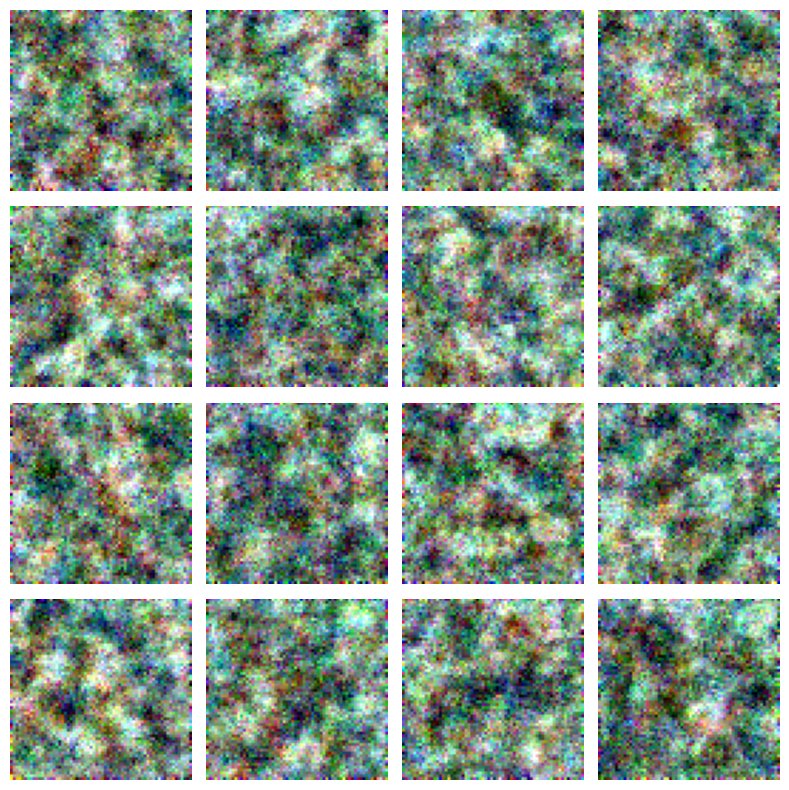

[ERFOLG] Bilder im Drive unter ./Alex_RM/Output_Images_FM abgelegt. Du kannst diese nun direkt mit den 'ddpm_final.pth' Outputs abgleichen!


In [9]:
# Da die Pfade in Phase 2 (RF) deterministisch begradigt wurden,
# kann das RF-Modell Bilder in deutlich weniger (oder gar einem einzigen) Schritt generieren!

print("[INFO] Generiere Bilder mit dem Rectified Flow (RF) Modell...")
# Generierung über 50 Integrationsschritte
Bilder_RF_MultiStep = Generiere_Bilder_Flow_Matching(Modell_RF, anzahl_bilder=16, steps=50)

# Generierung in nur 1 Einzeschritt (Direktprognose bei t=0)
Modell_RF.eval()
with torch.no_grad():
    x0_test = torch.randn((16, 3, IMAGE_SIZE, IMAGE_SIZE), device=Device)
    t_zero = torch.zeros((16,), device=Device)
    v_zero = Modell_RF(x0_test, t_zero)
    # x1 = x0 + v
    Bilder_RF_1Step = Entferne_Normierung(x0_test + v_zero)

# Plotten des 1-Schritt Ergebnisses zum visuellen Qualitäts-Vergleich mit DDPM
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
Bilder_RF_1Step = Bilder_RF_1Step.cpu().permute(0, 2, 3, 1).numpy()

for i, ax in enumerate(axes.flat):
    ax.imshow(Bilder_RF_1Step[i])
    ax.axis('off')

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT_IMAGES + "/rectified_flow_1step_output.png")
plt.show()
print(f"[ERFOLG] Bilder im Drive unter {DRIVE_OUTPUT_IMAGES} abgelegt. Du kannst diese nun direkt mit den 'ddpm_final.pth' Outputs abgleichen!")